In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scaling
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, DBSCAN

# Evaluation
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("wine.csv")

In [4]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [7]:
df.shape

(178, 14)

In [9]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [10]:
df.duplicated().sum()

0

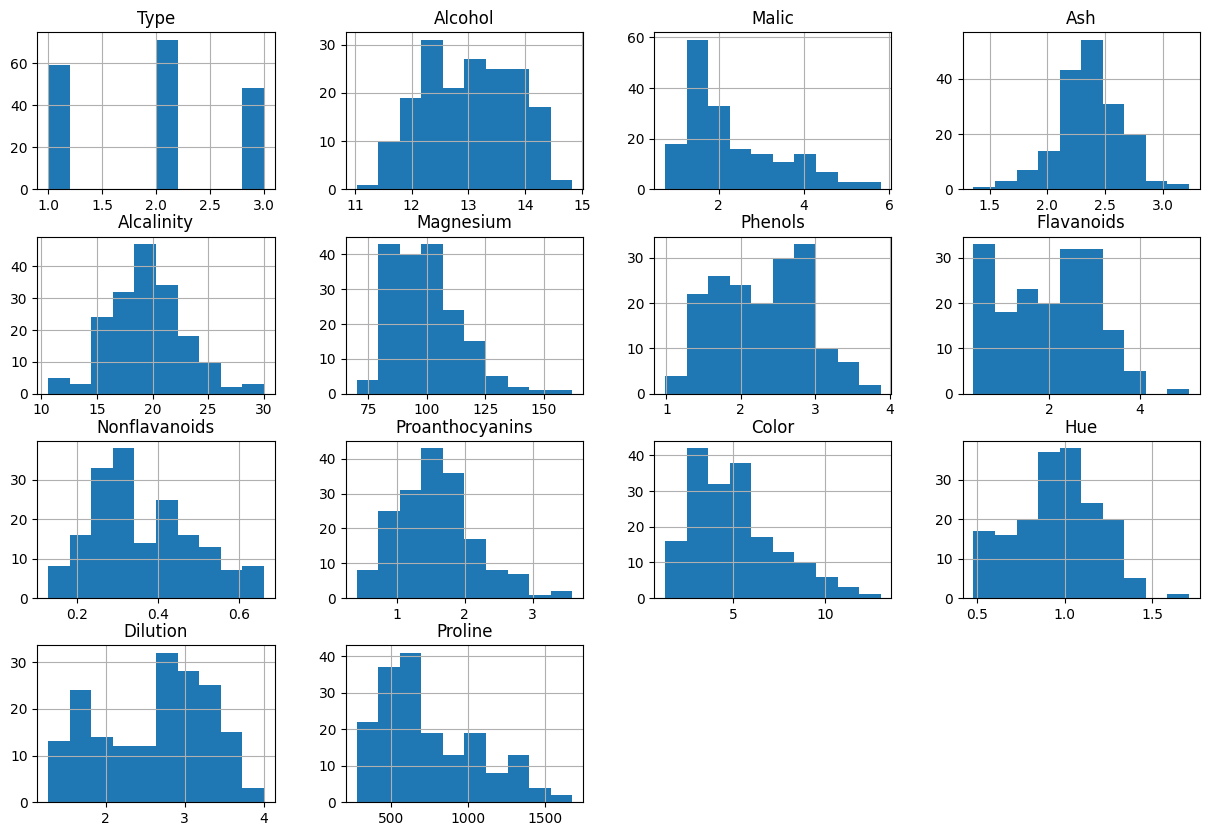

In [11]:
df.hist(figsize=(15,10))
plt.show()

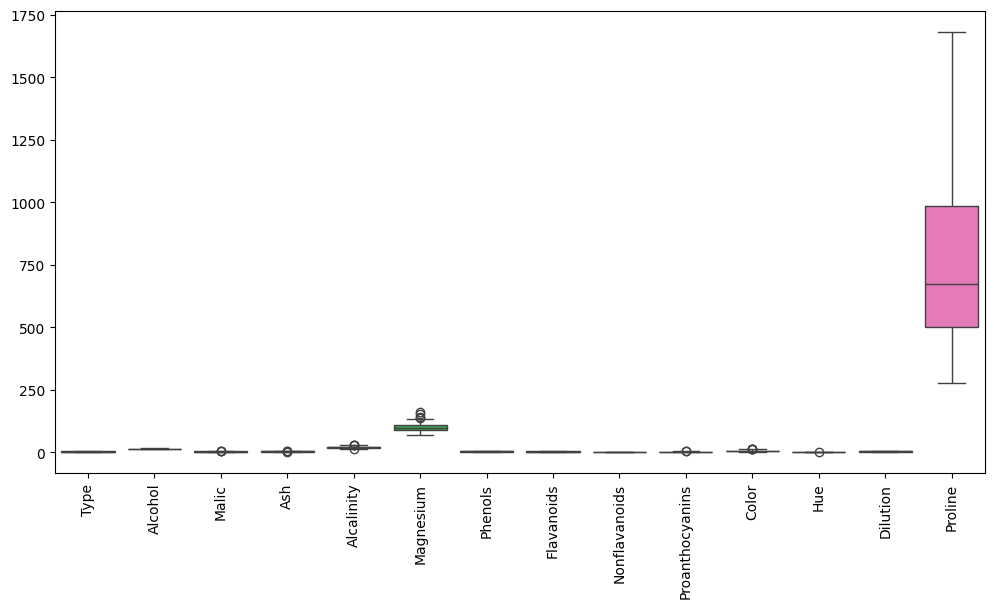

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

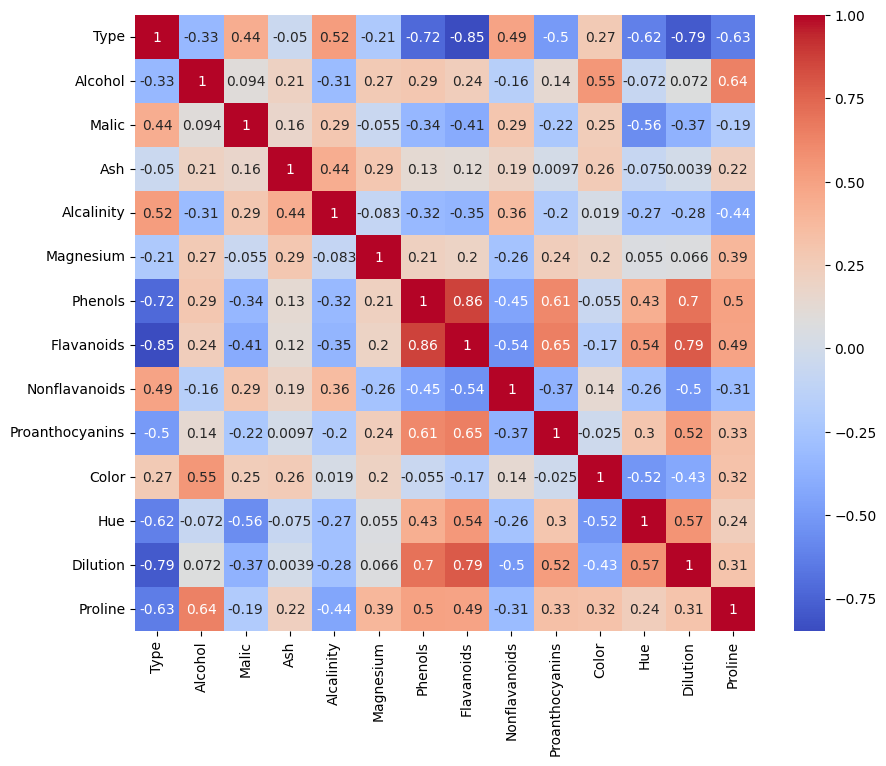

In [13]:
# Correlation Matrix
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [14]:
# Separate Features
X = df.drop("Type", axis=1)

In [15]:
# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
# Elbow Method for K-Means
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

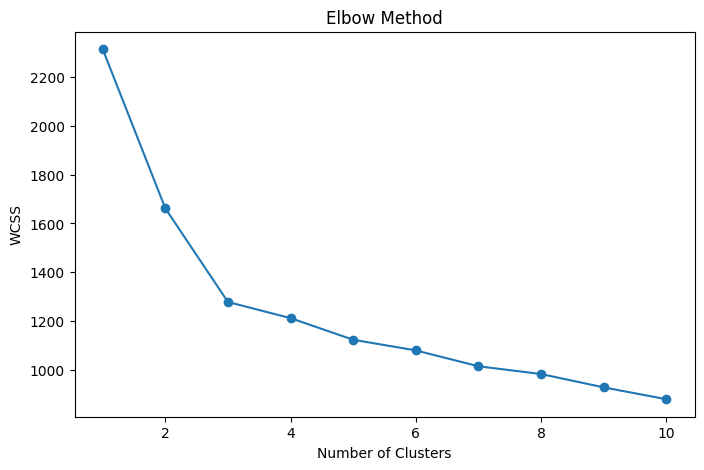

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [18]:
# Apply K-Means
# Assume K = 3
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_clusters = kmeans.fit_predict(X_scaled)

In [19]:
# K-Means Silhouette Score
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_clusters
)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.2848589191898987


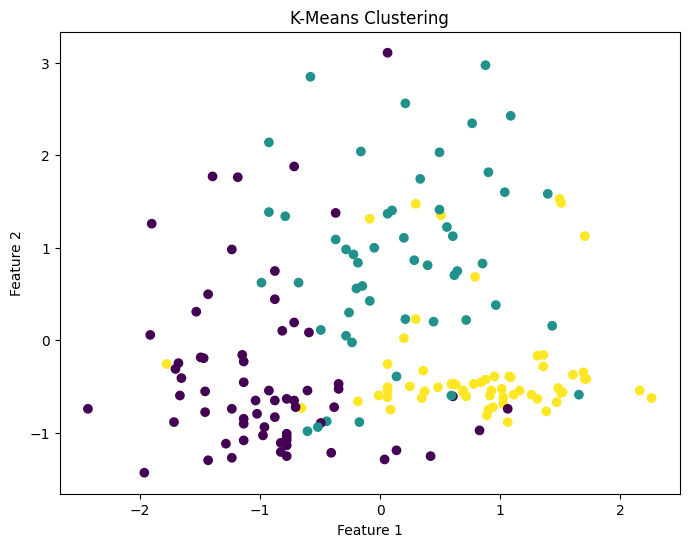

In [20]:
# K-Means Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_clusters
)

plt.title("K-Means Clustering")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [21]:
# Apply DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(X_scaled)

In [22]:
# DBSCAN Unique Clusters
print(np.unique(dbscan_clusters))

[-1]


In [23]:
# DBSCAN Silhouette Score
if len(set(dbscan_clusters)) > 1:

    dbscan_score = silhouette_score(
        X_scaled,
        dbscan_clusters
    )

    print("DBSCAN Score:", dbscan_score)

else:
    print("Silhouette Score cannot be calculated")

Silhouette Score cannot be calculated


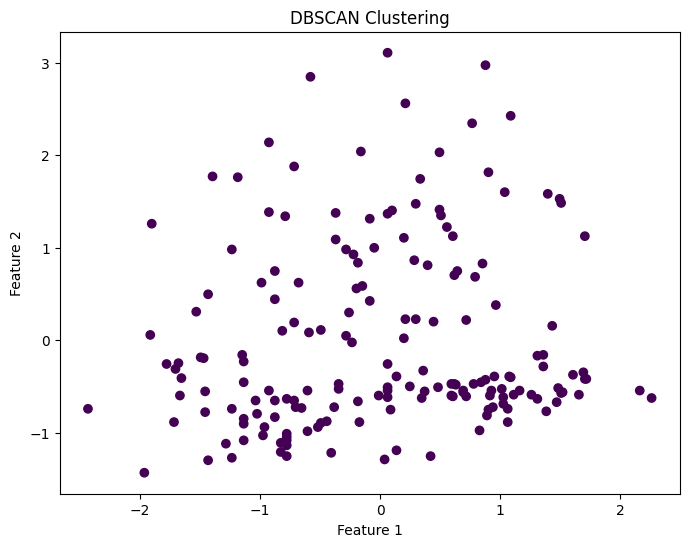

In [24]:
# DBSCAN Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=dbscan_clusters
)

plt.title("DBSCAN Clustering")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [ ]:
#Comparison Table
comparison = pd.DataFrame({

    'Algorithm': ['K-Means', 'DBSCAN'],

    'Silhouette Score': [
        kmeans_score,
        dbscan_score
    ]
})

print(comparison)

Final Conclusion
K-Means and DBSCAN clustering algorithms were applied successfully.

K-Means created well-separated clusters using centroid-based clustering.

DBSCAN detected dense regions and identified noise points effectively.

Silhouette Score was used to evaluate clustering quality.

K-Means works better for spherical clusters, while DBSCAN handles noise and irregular shapes efficiently.